# Bland-Altman


## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


## CONFIGURACIÓN - Edita aquí

In [ ]:
# Ruta del archivo Excel
ARCHIVO_DATOS = 'datos_vesicula.xlsx'

# Parámetros GLOBALES de estilo
COLOR_PUNTOS = 'steelblue'      # Color de los puntos scatter
COLOR_BORDE = 'navy'             # Color del borde de los puntos
SIZE_PUNTOS = 150                # Tamaño de los puntos
ALPHA_PUNTOS = 0.6               # Transparencia (0-1)
LINEWIDTH_BORDE = 1.5            # Grosor del borde

COLOR_SESGO = 'red'              # Color línea de sesgo
LINEWIDTH_SESGO = 2.5            # Grosor línea de sesgo

COLOR_LOA = 'gray'               # Color límites LoA
LINESTYLE_LOA = '--'             # Estilo línea LoA (- para sólida, -- para punteada, -. para otra)
LINEWIDTH_LOA = 1.5              # Grosor línea LoA

DPI = 300                        # Resolución de las imágenes

print('Parámetros globales configurados')

Parámetros globales configurados


## GRÁFICOS - Edita títulos y etiquetas

In [ ]:
# CONFIGURACIÓN DE CADA GRÁFICO - Puedes editar todos estos parámetros
GRAFICOS = [
    # GRÁFICO 1: Longitud Manual vs Multiclase
    {
        'method1': 'Longitud manual',
        'method2': 'Longitud Multiclase',
        'label1': 'Manual',
        'label2': 'Multiclase',
        'titulo': 'Longitud Vesícula: Manual vs Multiclase',
        'xlabel': 'Media de Manual y Multiclase',
        'ylabel': 'Diferencia (Manual - Multiclase)',
        'archivo': '01_longitud_multiclase.png',
        'tamaño': (10, 7),
        'fontsize_titulo': 13,
        'fontsize_label': 12,
        'fontsize_legend': 10,
    },
    # GRÁFICO 2: Longitud Manual vs Binario
    {
        'method1': 'Longitud manual',
        'method2': 'Longitud binario',
        'label1': 'Manual',
        'label2': 'Binario',
        'titulo': 'Longitud Vesícula: Manual vs Binario',
        'xlabel': 'Media de Manual y Binario',
        'ylabel': 'Diferencia (Manual - Binario)',
        'archivo': '02_longitud_binario.png',
        'tamaño': (10, 7),
        'fontsize_titulo': 13,
        'fontsize_label': 12,
        'fontsize_legend': 10,
    },
    # GRÁFICO 3: Ancho Manual vs Multiclase
    {
        'method1': 'Ancho manual',
        'method2': 'Ancho multiclase',
        'label1': 'Manual',
        'label2': 'Multiclase',
        'titulo': 'Ancho Vesícula: Manual vs Multiclase',
        'xlabel': 'Media de Manual y Multiclase',
        'ylabel': 'Diferencia (Manual - Multiclase)',
        'archivo': '03_ancho_multiclase.png',
        'tamaño': (10, 7),
        'fontsize_titulo': 13,
        'fontsize_label': 12,
        'fontsize_legend': 10,
    },
    # GRÁFICO 4: Ancho Manual vs Binario
    {
        'method1': 'Ancho manual',
        'method2': 'Ancho binario',
        'label1': 'Manual',
        'label2': 'Binario',
        'titulo': 'Ancho Vesícula: Manual vs Binario',
        'xlabel': 'Media de Manual y Binario',
        'ylabel': 'Diferencia (Manual - Binario)',
        'archivo': '04_ancho_binario.png',
        'tamaño': (10, 7),
        'fontsize_titulo': 13,
        'fontsize_label': 12,
        'fontsize_legend': 10,
    },
    # GRÁFICO 5: Cálculo Manual vs Multiclase
    {
        'method1': 'Calculo reporte',
        'method2': 'Calculo multiclase',
        'label1': 'Manual',
        'label2': 'Multiclase',
        'titulo': 'Diámetro Máximo Cálculo: Manual vs Multiclase',
        'xlabel': 'Media de Manual y Multiclase',
        'ylabel': 'Diferencia (Manual - Multiclase)',
        'archivo': '05_calculo_multiclase.png',
        'tamaño': (10, 7),
        'fontsize_titulo': 13,
        'fontsize_label': 12,
        'fontsize_legend': 10,
        'indices': (10, 20),  # Solo para cálculos (filas 10-20)
    },
    # GRÁFICO 6: Cálculo Manual vs Binario
    {
        'method1': 'Calculo reporte',
        'method2': 'Calculo binario',
        'label1': 'Manual',
        'label2': 'Binario',
        'titulo': 'Diámetro Máximo Cálculo: Manual vs Binario',
        'xlabel': 'Media de Manual y Binario',
        'ylabel': 'Diferencia (Manual - Binario)',
        'archivo': '06_calculo_binario.png',
        'tamaño': (10, 7),
        'fontsize_titulo': 13,
        'fontsize_label': 12,
        'fontsize_legend': 10,
        'indices': (10, 20),  # Solo para cálculos (filas 10-20)
    },
]

print(f'Configurados {len(GRAFICOS)} gráficos')

Configurados 6 gráficos


## Función Bland-Altman

In [ ]:
def bland_altman_plot(ax, method1, method2, label1, label2, titulo,
                      xlabel, ylabel, fontsize_titulo, fontsize_label, fontsize_legend):
    """
    Crea un gráfico de Bland-Altman con todas las estadísticas
    """
    # Calcular media y diferencia
    mean = (method1 + method2) / 2
    diff = method1 - method2

    # Estadísticas
    md = np.mean(diff)  # sesgo
    sd = np.std(diff, ddof=1)  # desviación estándar
    ci = 1.96  # para intervalo de confianza 95%

    upper_loa = md + ci * sd
    lower_loa = md - ci * sd

    # Plotear scatter
    ax.scatter(mean, diff, alpha=ALPHA_PUNTOS, s=SIZE_PUNTOS,
              color=COLOR_PUNTOS, edgecolors=COLOR_BORDE, linewidth=LINEWIDTH_BORDE)

    # Línea de sesgo
    ax.axhline(md, color=COLOR_SESGO, linestyle='-', linewidth=LINEWIDTH_SESGO,
              label=f'Media: {md:.2f}')

    # Límites de acuerdo (LoA)
    ax.axhline(upper_loa, color=COLOR_LOA, linestyle=LINESTYLE_LOA, linewidth=LINEWIDTH_LOA,
              label=f'LoA superior: {upper_loa:.2f}')
    ax.axhline(lower_loa, color=COLOR_LOA, linestyle=LINESTYLE_LOA, linewidth=LINEWIDTH_LOA,
              label=f'LoA inferior: {lower_loa:.2f}')

    # Formato de ejes y etiquetas
    ax.set_xlabel(xlabel, fontsize=fontsize_label)
    ax.set_ylabel(ylabel, fontsize=fontsize_label)
    ax.legend(fontsize=fontsize_legend, loc='best', framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle=':')

    return md, sd, upper_loa, lower_loa

print('Función bland_altman_plot definida')

Función bland_altman_plot definida


## Cargar Datos

In [ ]:
print(f"Leyendo datos desde: {ARCHIVO_DATOS}\n")
df = pd.read_excel(ARCHIVO_DATOS)
print(f"Datos cargados: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"\nColumnas disponibles:\n{df.columns.tolist()}")

Leyendo datos desde: datos_vesicula.xlsx

Datos cargados: 20 filas, 11 columnas

Columnas disponibles:
['Estudio', 'Barrido', 'Longitud Multiclase', 'Ancho multiclase', 'Longitud binario', 'Ancho binario', 'Longitud manual', 'Ancho manual', 'Calculo multiclase', 'Calculo binario', 'Calculo reporte']


## Generar Gráficos

In [ ]:
print("="*60)
print("GENERANDO GRÁFICOS BLAND-ALTMAN SEPARADOS")
print("="*60 + "\n")

for idx, config in enumerate(GRAFICOS, 1):
    # Obtener datos
    col_method1 = config['method1']
    col_method2 = config['method2']

    # Si hay índices especificados (para cálculos), usarlos
    if 'indices' in config:
        start, end = config['indices']
        method1 = df[col_method1].iloc[start:end].dropna().values
        method2 = df[col_method2].iloc[start:end].dropna().values
    else:
        method1 = df[col_method1].values
        method2 = df[col_method2].values

    # Crear figura
    fig, ax = plt.subplots(figsize=config['tamaño'])

    md, sd, ul, ll = bland_altman_plot(
        ax, method1, method2,
        config['label1'], config['label2'],
        config['titulo'],
        config['xlabel'],
        config['ylabel'],
        config['fontsize_titulo'],
        config['fontsize_label'],
        config['fontsize_legend']
    )

    # Guardar
    plt.tight_layout()
    plt.savefig(config['archivo'], dpi=DPI, bbox_inches='tight')
    plt.close()

    print(f"{idx}. {config['archivo']:40} - OK ({len(method1)} muestras)")
    print(f"   Sesgo: {md:7.2f} | SD: {sd:6.2f} | LoA: [{ll:7.2f}, {ul:7.2f}]\n")

print("="*60)
print("✓ Todos los gráficos generados exitosamente")
print("="*60)

GENERANDO GRÁFICOS BLAND-ALTMAN SEPARADOS

1. 01_longitud_multiclase.png               - OK (20 muestras)
   Sesgo:   -0.23 | SD:   2.00 | LoA: [  -4.15,    3.69]

2. 02_longitud_binario.png                  - OK (20 muestras)
   Sesgo:   -0.37 | SD:   2.40 | LoA: [  -5.06,    4.33]

3. 03_ancho_multiclase.png                  - OK (20 muestras)
   Sesgo:   -0.05 | SD:   2.37 | LoA: [  -4.69,    4.60]

4. 04_ancho_binario.png                     - OK (20 muestras)
   Sesgo:   -0.19 | SD:   2.15 | LoA: [  -4.40,    4.03]

5. 05_calculo_multiclase.png                - OK (10 muestras)
   Sesgo:   -0.15 | SD:   1.29 | LoA: [  -2.68,    2.38]

6. 06_calculo_binario.png                   - OK (10 muestras)
   Sesgo:   -0.55 | SD:   2.27 | LoA: [  -5.00,    3.91]

✓ Todos los gráficos generados exitosamente


## Vista Previa (Opcional)

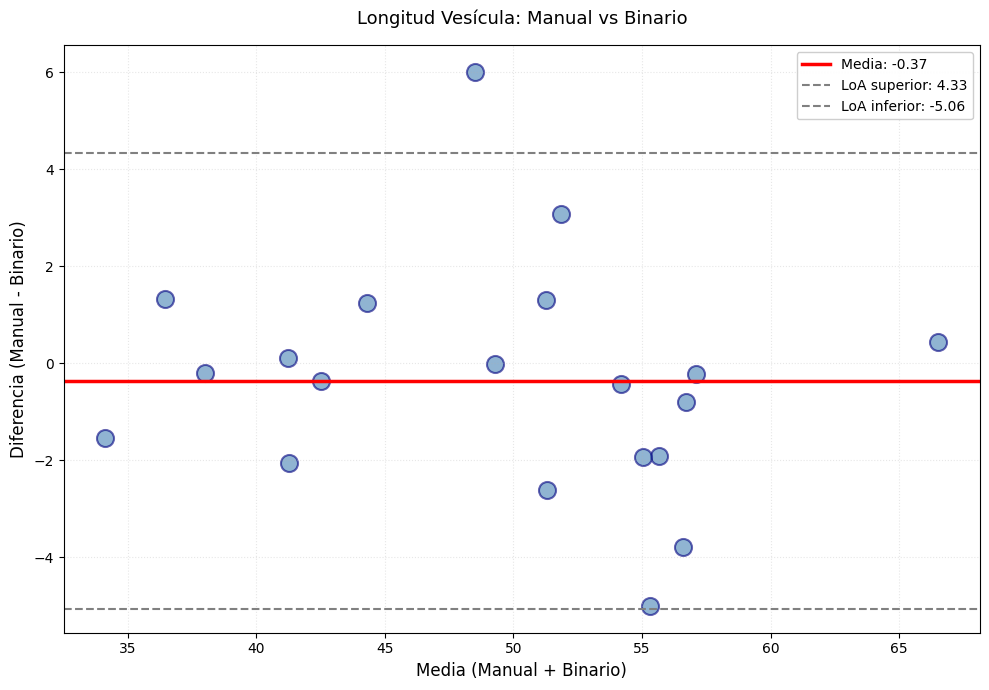

Vista previa: Longitud Vesícula: Manual vs Binario


In [ ]:
# Mostrar vista previa del primer gráfico
config = GRAFICOS[1]
col_method1 = config['method1']
col_method2 = config['method2']
method1 = df[col_method1].values
method2 = df[col_method2].values

fig, ax = plt.subplots(figsize=config['tamaño'])
bland_altman_plot(
    ax, method1, method2,
    config['label1'], config['label2'],
    config['titulo'],
    config['xlabel'],
    config['ylabel'],
    config['fontsize_titulo'],
    config['fontsize_label'],
    config['fontsize_legend']
)
plt.tight_layout()
plt.show()

print(f"Vista previa: {config['titulo']}")

In [ ]:
pip install pingouin pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 2.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import pingouin as pg

# Datos: cada fila es un estudio con las mediciones de cada método
data = [
["3636",57.3,29.2,57.2,29.2,56.98,24.99,None,None,None],
["3691",49.8,21.6,52.6,21.7,49.98,24.59,None,None,None],
["3719",35.7,18.6,38.1,20,37.9,21.35,None,None,None],
["3757",40.8,21.6,41.2,22.6,41.31,21.5,None,None,None],
["3782",55.3,20.2,56.6,20.5,56.3,20.27,None,None,None],
["3814",56.8,28.1,57.1,26.4,56.3,28.47,None,None,None],
["3842",53.9,21.9,56,22.4,54.07,22.2,None,None,None],
["3855",40.2,31,42.3,30.4,40.25,32.52,None,None,None],
["3860",49.5,23.3,45.5,24.4,51.5,24.74,None,None,None],
["4001",48.9,26.1,49.3,25.7,49.28,25.6,None,None,None],
["7760",52.2,31.3,50.6,33.8,51.9,32.8,27.6,29.1,28],
["4498",59.1,35.8,58.5,36.2,54.72,35.07,22.6,21.4,25],
["7618",33.7,15,35.8,15,37.13,16.76,14.8,16,16],
["7394",68.3,36.1,66.3,36.2,66.74,37.45,22.3,22.3,21],
["7341",52.4,21.7,50.3,21.8,53.37,22.02,21.36,18,20],
["4270",34.9,27.8,34.9,25.8,33.37,24.8,13.5,13.4,13],
["4520",57.5,46.6,57.8,44.8,52.8,41.33,13.1,13.6,12],
["4874",52.8,44.6,54.4,43.3,53.97,46.41,18.2,17.1,17.48],
["4717",45,25.3,42.7,25.5,42.34,21.38,13.9,17.1,12.58],
["4120",44.5,37.1,43.7,40.7,44.95,38.9,23,26.3,23.79],
]

cols = ["estudio","long_multi","ancho_multi","long_bin","ancho_bin",
        "long_manual","ancho_manual","calc_multi","calc_bin","calc_reporte"]
df = pd.DataFrame(data, columns=cols)

# Pares a comparar: (columna_software, columna_referencia)
pairs = {
    "Ancho (multiclase vs manual)": ["ancho_multi","ancho_manual"],
    "Ancho (binario vs manual)": ["ancho_bin","ancho_manual"],
    "Longitud (multiclase vs manual)": ["long_multi","long_manual"],
    "Longitud (binario vs manual)": ["long_bin","long_manual"],
    "Calculo (multiclase vs reporte)": ["calc_multi","calc_reporte"],
    "Calculo (binario vs reporte)": ["calc_bin","calc_reporte"],
}

for name, cols_pair in pairs.items():
    d = df.dropna(subset=cols_pair)  # excluye los "x" (NaN) para las medidas del cálculo
    # Formato largo: una fila por estudio+método
    long = d.melt(id_vars=["estudio"], value_vars=cols_pair,
                  var_name="metodo", value_name="valor")
    icc = pg.intraclass_corr(data=long, targets="estudio",
                              raters="metodo", ratings="valor")
    a1 = icc[icc["Type"]=="ICC(A,1)"].iloc[0]  # dos vías, aleatorio, absoluta, medición única
    c1 = icc[icc["Type"]=="ICC(C,1)"].iloc[0]  # dos vías, mixto, consistencia (referencia)
    print(f"\n=== {name} (n={len(d)}) ===")
    print(f"ICC(A,1) [dos vías, aleatorio, absoluta]: {a1['ICC']:.3f}  IC95%[{a1['CI95'][0]:.3f}, {a1['CI95'][1]:.3f}]  p={a1['pval']:.4f}")
    print(f"ICC(C,1) [dos vías, mixto, consistencia]: {c1['ICC']:.3f}  IC95%[{c1['CI95'][0]:.3f}, {c1['CI95'][1]:.3f}]  p={c1['pval']:.4f}")


=== Ancho (multiclase vs manual) (n=20) ===
ICC(A,1) [dos vías, aleatorio, absoluta]: 0.962  IC95%[0.910, 0.980]  p=0.0000
ICC(C,1) [dos vías, mixto, consistencia]: 0.960  IC95%[0.900, 0.980]  p=0.0000

=== Ancho (binario vs manual) (n=20) ===
ICC(A,1) [dos vías, aleatorio, absoluta]: 0.967  IC95%[0.920, 0.990]  p=0.0000
ICC(C,1) [dos vías, mixto, consistencia]: 0.966  IC95%[0.920, 0.990]  p=0.0000

=== Longitud (multiclase vs manual) (n=20) ===
ICC(A,1) [dos vías, aleatorio, absoluta]: 0.974  IC95%[0.940, 0.990]  p=0.0000
ICC(C,1) [dos vías, mixto, consistencia]: 0.973  IC95%[0.930, 0.990]  p=0.0000

=== Longitud (binario vs manual) (n=20) ===
ICC(A,1) [dos vías, aleatorio, absoluta]: 0.963  IC95%[0.910, 0.980]  p=0.0000
ICC(C,1) [dos vías, mixto, consistencia]: 0.961  IC95%[0.900, 0.980]  p=0.0000

=== Calculo (multiclase vs reporte) (n=10) ===
ICC(A,1) [dos vías, aleatorio, absoluta]: 0.973  IC95%[0.900, 0.990]  p=0.0000
ICC(C,1) [dos vías, mixto, consistencia]: 0.971  IC95%[0.890,